In [10]:
import urllib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json

## Start by loading the data we need

In [ ]:
with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/edges/all_party_edges.csv") as response:
    df_party_edges = pd.read_csv(response)

with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/party_colors.json") as response:
    party_colors = json.load(response)
from folketingsperioder import periods_df  #Use this to show which government
periods_df['Period'] = periods_df["Period"].astype(int)

all_parties = list(set(list(list(df_party_edges['source'].unique()) + list(df_party_edges['target'].unique()))))
all_periods = df_party_edges['Period'].unique()
all_topics = df_party_edges['topic'].unique()
print(f"Data for {len(all_parties)} parties: {all_parties}")
print(f"Data for {len(all_periods)} periods: {all_periods}")
print(f"Data for {len(all_topics)} topics: {all_topics}")

Data for 27 parties: ['Alternativet', 'Javnaðarflokkurin', 'Ny Alliance', 'Uden for folketingsgrupperne', 'Kristendemokraterne', 'Nunatta Qitornai', 'Sambandsflokkurin', 'Venstre', 'Folkaflokkurin', 'Socialdemokratiet', 'Socialistisk Folkeparti', 'Borgernes Parti', 'Kristeligt Folkeparti', 'Tjóðveldisflokkurin', 'Inuit Ataqatigiit', 'Moderaterne', 'Danmarksdemokraterne', 'Radikale Venstre', 'Liberal Alliance', 'Not able to assign', 'Siumut', 'Frie Grønne', 'Enhedslisten', 'Tjóðveldi', 'Naleraq', 'Det Konservative Folkeparti', 'Dansk Folkeparti']
Data for 7 periods: [65 66 67 68 69 70 71]
Data for 15 topics: ['finans_budget' 'klima_miljø' 'erhverv' 'retspolitik' 'uddannelse' 'skat'
 'arbejdsmarked_velfærd' 'social_familie' 'forsvar_sikkerhed'
 'udenrigs_eu' 'transport_infrastruktur' 'sundhed' 'immigration' 'bolig'
 'General']


In [12]:
df_party_edges

,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Danmarksdemokraterne,Danmarksdemokraterne,65,386,382.0,0.989637,finans_budget
1,Danmarksdemokraterne,Dansk Folkeparti,65,6220,6182.0,0.993891,finans_budget
2,Danmarksdemokraterne,Det Konservative Folkeparti,65,3613,3585.0,0.992250,finans_budget
3,Danmarksdemokraterne,Enhedslisten,65,93,40.0,0.430108,finans_budget
4,Danmarksdemokraterne,Inuit Ataqatigiit,65,30,3.0,0.100000,finans_budget
...,...,...,...,...,...,...,...
13583,Socialistisk Folkeparti,Uden for folketingsgrupperne,71,30387,20806.0,0.684701,General
13584,Socialistisk Folkeparti,Venstre,71,178905,130250.0,0.728040,General
13585,Uden for folketingsgrupperne,Uden for folketingsgrupperne,71,3016,2068.0,0.685676,General
13586,Uden for folketingsgrupperne,Venstre,71,51308,41721.0,0.813148,General


C:\Users\ThorNørgaardEriksen\AppData\Local\Temp\ipykernel_37492\884296435.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_primary_as_target.rename(columns = {"target": "source", "source": "target"}, inplace = True)


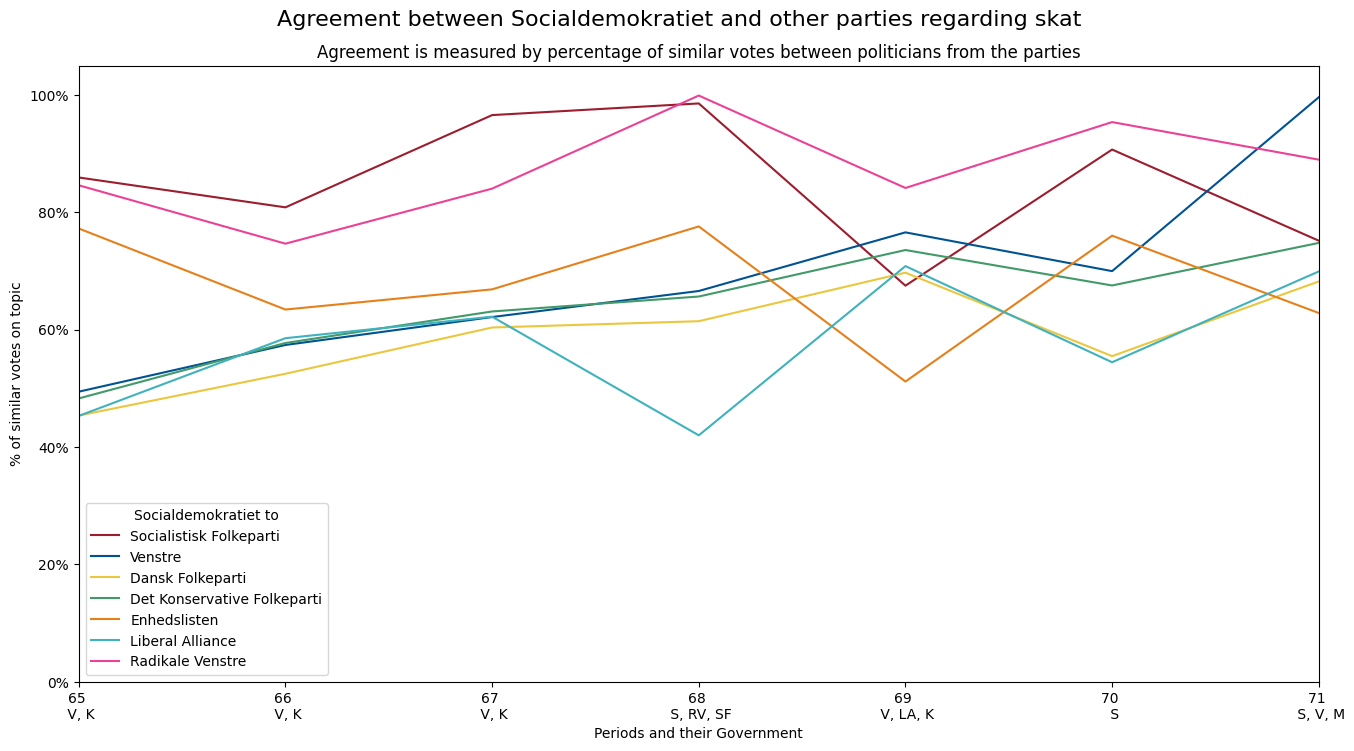

In [30]:
#Get the relevant rows
def visualize_agreement_for(df_party_edges, topic, party_1):
    df_topic = df_party_edges[df_party_edges['topic'] == topic]

    #Remove self_edges
    df_topic = df_topic[df_topic['source'] != df_topic['target']]


    traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
    # parties_to_drop_momentarily = ['Kirsteligt Folkeparti', "Not able to assign", Ny Alliance]
    mask_only_traditional_parties = (df_topic['source'].isin(traditional_parties)) & (df_topic['target'].isin(traditional_parties))
    df_topic_traditional = df_topic[mask_only_traditional_parties]


    # We start by re-creating the dataframe, so we can use target as "other party"
    primary_as_source_mask = (df_topic_traditional['source'] == party_1)
    primary_as_target_mask = (df_topic_traditional['target'] == party_1)
    df_primary_as_source = df_topic_traditional[primary_as_source_mask]
    df_primary_as_target = df_topic_traditional[primary_as_target_mask]

    #Rename the columns to match 
    df_primary_as_target.rename(columns = {"target": "source", "source": "target"}, inplace = True)

    #Create the dataframe for the party only
    df_party = pd.concat([df_primary_as_source, df_primary_as_target])

    # mask_1 = (df_topic_traditional['source'] == party_1) & (df_topic_traditional['target'] != party_1) #Old mask
    # mask_2 = (df_topic_traditional['target'] != party_1)
    # df_masked  = df_topic_traditional[mask_2]
    df_masked = df_party
    

    #Get the governments for viz
    govs_and_period = []
    periods = df_party_edges['Period'].unique()
    for period in periods:
        gov = periods_df.loc[(periods_df.Period == period), "Regering"].values[0]
        govs_and_period.append(f"{period} \n {gov}")

    # Assign the colors based on the party
    plot_colors = []
    for party in df_masked["target"].unique():
        try:
            party_color = party_colors[party]
        except:
            party_color = party_colors["Andre"] #Set it to grey
        plot_colors.append(party_color)
    relevant_palette = sns.color_palette(plot_colors)


    figure, axs = plt.subplots(1,1,figsize = (16,8)) #Width, Height
    plt.suptitle(f"Agreement between {party_1} and other parties regarding {topic}", fontsize = 16, x = 0.5, y = 0.95)
    plt.title(f"Agreement is measured by percentage of similar votes between politicians from the parties")
    sns.lineplot(data = df_masked, x = "Period", y = "weight", hue = "target", ax = axs, palette=relevant_palette)

    #Settings for the xaxis
    axs.set_xlim(65, 71)
    axs.set_xticks(periods)
    axs.set_xticklabels(govs_and_period)
    axs.set_xlabel(xlabel="Periods and their Government")

    #Settings for y-axis
    axs.set_ylim(0,1.05)
    axs.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axs.set_ylabel("% of similar votes on topic")

    #Legend setting
    axs.legend(title = f"{party_1} to")

    #Show
    plt.show()
    # return df_party

visualize_agreement_for(df_party_edges, topic = "skat", party_1="Socialdemokratiet")
